In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import umap

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_clusters = pd.read_pickle("documentos_2004_2024_preprocesados.pkl")

print("Shape:", df_clusters.shape)
print("Tipo de resuelve_tokens:", type(df_clusters["resuelve_tokens"].iloc[0]))
print(df_clusters["resuelve_tokens"].head(3).to_list())

Shape: (23518, 8)
Tipo de resuelve_tokens: <class 'list'>
[['modificar', 'prestacion', 'servicios', 'salud', 'sistema', 'seguridad', 'social'], ['aprobar', 'presupuesto', 'fondos', 'generales', 'vigencia', 'fiscal'], ['aprobar', 'presupuesto', 'fondos', 'seguridad', 'social', 'vigencia', 'fiscal']]


In [3]:
df_clusters["resuelve_doc"] = df_clusters["resuelve_tokens"].apply(lambda toks: " ".join(toks))

print(df_clusters["resuelve_doc"].head(3).to_list())

['modificar prestacion servicios salud sistema seguridad social', 'aprobar presupuesto fondos generales vigencia fiscal', 'aprobar presupuesto fondos seguridad social vigencia fiscal']


In [4]:
docs = df_clusters["resuelve_doc"].fillna("").tolist()

model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

embeddings = embedder.encode(
    docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Shape embeddings:", embeddings.shape)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2622.30it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 368/368 [05:51<00:00,  1.05it/s]


Shape embeddings: (23518, 384)


In [6]:
# Guardado opcional para no recalcular
np.save("embeddings_resuelve_umap.npy", embeddings)

In [7]:
reducer = umap.UMAP(
    n_neighbors=15,
    n_components=10,
    metric="cosine",
    random_state=42
)

embeddings_reducidos = reducer.fit_transform(embeddings)

print("Shape embeddings reducidos:", embeddings_reducidos.shape)

c:\Users\sebas\Documents\VS_Studio_code\modelo_computacional\Modelo_computacional\entorno_virtual\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape embeddings reducidos: (23518, 10)


In [8]:
# Guardar embeddings reducidos
np.save("embeddings_resuelve_umap.npy", embeddings_reducidos)

In [9]:
resultados_kmeans = []

for k in range(5, 31):
    modelo = KMeans(
        n_clusters=k,        # cantidad de clusters a probar
        random_state=42,     # hace reproducible el resultado
        n_init=20            # múltiples inicializaciones, escoge la mejor por inercia
    )
    labels = modelo.fit_predict(embeddings_reducidos)
    resultados_kmeans.append({
        "k": k,
        "inercial": modelo.inertia_
    })

# Convertir a DataFrame
resultados_kmeans = pd.DataFrame(resultados_kmeans)

print(resultados_kmeans)

     k       inercial
0    5  200529.812500
1    6  181622.812500
2    7  165717.359375
3    8  149846.875000
4    9  136727.953125
5   10  125172.906250
6   11  118393.234375
7   12  109432.007812
8   13  100741.531250
9   14   95821.804688
10  15   88390.000000
11  16   83471.445312
12  17   78692.546875
13  18   74756.195312
14  19   71685.351562
15  20   67757.781250
16  21   63925.808594
17  22   60564.773438
18  23   57468.648438
19  24   55701.929688
20  25   53544.851562
21  26   50608.375000
22  27   48114.734375
23  28   46495.757812
24  29   44711.785156
25  30   42341.820312


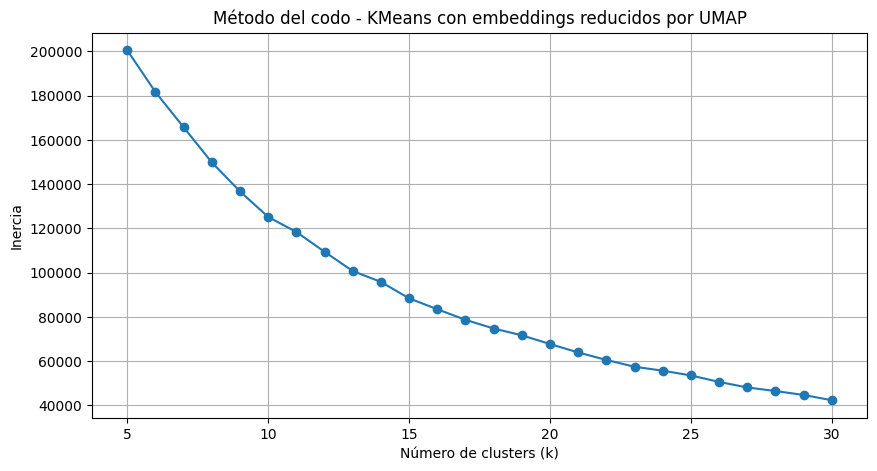

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(resultados_kmeans["k"], resultados_kmeans["inercial"], marker="o")
plt.title("Método del codo - KMeans con embeddings reducidos por UMAP")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [12]:
resultados_kmeans.to_excel("resultados_kmeans_umap.xlsx", index=False)
resultados_kmeans.to_csv("resultados_kmeans_umap.csv", index=False)

In [13]:
best_k = 10

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df_clusters["cluster_kmeans"] = kmeans_final.fit_predict(embeddings_reducidos)

print(df_clusters["cluster_kmeans"].value_counts().sort_index())


cluster_kmeans
0    6461
1    3866
2    3391
3     158
4    3148
5     458
6    4611
7      76
8    1291
9      58
Name: count, dtype: int64


In [14]:
for c in sorted(df_clusters["cluster_kmeans"].unique()):
    print(f"\n===== CLUSTER KMEANS {c} =====")
    
    muestra = df_clusters.loc[
        df_clusters["cluster_kmeans"] == c,
        ["resuelve", "resuelve_tokens"]
    ].head(8) 

    for _, fila in muestra.iterrows():
        print("Texto:", fila["resuelve"])
        print("Tokens:", fila["resuelve_tokens"])
        print("-" * 100)


===== CLUSTER KMEANS 0 =====
Texto: modificar articulos 45 66 y 74 del acuerdo superior 230 del 5 de agosto de 2002 estatuto de carrera administrativa
Tokens: ['modificar', 'articulos', 'estatuto', 'carrera']
----------------------------------------------------------------------------------------------------
Texto: modificar acuerdo superior 113 del 19 de mayo de 1997 reglamenta sistema general de viaticos
Tokens: ['modificar', 'reglamenta', 'sistema', 'general', 'viaticos']
----------------------------------------------------------------------------------------------------
Texto: aclarar articulo 33 del acuerdo superior 253 del 18 de febrero de 2003 estatuto profesor de catedra y ocasional
Tokens: ['aclarar', 'estatuto', 'catedra', 'ocasional']
----------------------------------------------------------------------------------------------------
Texto: adoptar reglamento interno consejo superior universitario
Tokens: ['adoptar', 'reglamento', 'interno']
--------------------------------

In [15]:
df_clusters.to_pickle("documentos_clusterizados_kmeans_umap.pkl")
df_clusters.to_excel("documentos_clusterizados_kmeans_umap.xlsx", index=False)